<a href="{{ colab_base_laboratorios }}/Laboratorio_06_normal_equations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab 6 : Ecuación normal

Se puede encontrar una solucion exacta para theta sin necesidad de emplear el gradiente descente de la sesiones pasadas, para ellos se puede encontrar el valor minimo de theta y a partir de alli determinar el valor de theta que minimiza J.

Los pasos para esta minimizacion se dejan como tarea, y pueden ser calculados según lo siguiente:

Si J es la funcion de coste dada por:

\begin{equation}
J(\theta_1,\theta_2,\theta_3, ...,\theta_n )=\frac{1}{2m} \sum_{i = 1}^m (\Theta^{T} X - \hat{y}^{(i)})^2
\end{equation}


Demostrar que:

- $J(\theta_1,\theta_2,\theta_3, ...,\theta_n ) = \frac{1}{2m} (\Theta ^ T X - y^T) (\Theta ^ T X - y^T)^T$

- $J= (\Theta ^T X) (\Theta ^T X)^T - 2(\Theta ^T X)Y  + Y^TY $


- $ \nabla _{\theta} J = \frac{1}{m} (2 X(X^T \Theta) -2XY)$


Para encontrar el valor minimo de \theta,  $\nabla _{\theta} J = 0$,

- $\Theta = (X^T X)^{-1} X^T y$



En este caso,tenemos que:

sea $X \in R^{n\times m}$ ,  $X^T \in R^{m\times n}$

sea $Y \in R^{m \times 1}$,  $Y^T \in R^{1 \times m}$

sea $\Theta \in R^{n \times 1}$, $\Theta^T \in R^{1 \times n}$




Para la demostracion anterior emplee las siguientes propiedades:

- $z^T z= \sum_i z_i^2$
- $a^T b = b^Ta$
- $\nabla _x b^T x = b$
- $\nabla _x  x^T A x = 2Ax$

donde a, b, x son matrices, $\nabla_x$ es la derivada respecto al vector x, y A es una matriz simétrica




1. Para los datos del laboratorio anterior aplicar la ecuacion normal.
2. Tomar el dataset de las casas de Boston y construir un modelo de regresión mutivariada.

```
# Tomar los datos de las casas de boston y hacer una regresion lineal tomando
# el average number of rooms per dwelling.
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

df = pd.DataFrame({"mean_":target, "rm":data[:,5]})

```

## Implementación computacional

## 1. Comparación con el Lab 5

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go

# datos de lab 5
N = 1000
x_1 = 2 * np.random.random(N) - 1 
x_2 = 2 * np.random.random(N) - 1
ruido = 0.5 * np.random.randn(N) 
y_label = 2.1 * x_1 - 3.1 * x_2 + ruido


df = pd.DataFrame({"x1": x_1, "x2": x_2, "y": y_label})
df["ones"] = 1

X = df[["ones", "x1", "x2"]].values.T  # (3, 100)
Y = df.y.values.reshape(1, N)          # (1, 100)

print("Dimensiones:")
print(f"X: {X.shape} ")
print(f"Y: {Y.shape}")


Dimensiones:
X: (3, 1000) 
Y: (1, 1000)


In [2]:
# ECUACIÓN NORMAL
# Θ = (X^T X)^-1 X^T y

#  X^T X
XTX = X @ X.T  # (3, 3)

#  inversa de X^T X
XTX_inv = np.linalg.inv(XTX)  # (3, 3)

#  X^T y
XTy = X @ Y.T  # (3, 1)

#  theta usando la ecuación normal
theta_normal = XTX_inv @ XTy  # (3, 1)

#  predicciones
h_normal = theta_normal.T @ X  # (1, 100)

# Calcular costo final
error = h_normal - Y
costo_final = float(np.mean(error ** 2) / 2)  # Error cuadrático medio (MSE/2)

In [3]:
# COMPARACIÓN CON GRADIENT DESCENTE

def model(theta, X):
    return theta.T @ X

def costo(h, Y):
    J = (h - Y) ** 2
    return J.mean() / 2

def update_params(theta, h, Y, X, learning_rate):
    grad = np.dot((h - Y), X.T).T
    theta = theta - learning_rate * grad
    return theta

theta_gd = np.random.random(3).reshape(3, 1)

learning_rate = 0.01
Niter = 1000
J_history = []

for i in range(Niter):
    h = model(theta_gd, X)
    J_history.append(costo(h, Y))
    theta_gd = update_params(theta_gd, h, Y, X, learning_rate)


print(f"\nGradient Descente:")
print(f"θ₀ = {theta_gd[0, 0]:.4f}")
print(f"θ₁ = {theta_gd[1, 0]:.4f}")
print(f"θ₂ = {theta_gd[2, 0]:.4f}")
print(f"Costo final: {J_history[-1]:.6f}")

print(f"\nEcuación Normal:")
print(f"θ₀ = {theta_normal[0, 0]:.4f}")
print(f"θ₁ = {theta_normal[1, 0]:.4f}")
print(f"θ₂ = {theta_normal[2, 0]:.4f}")
print(f"Costo final: {costo_final :.6f}")

 


Gradient Descente:
θ₀ = nan
θ₁ = nan
θ₂ = nan
Costo final: nan

Ecuación Normal:
θ₀ = -0.0076
θ₁ = 2.1159
θ₂ = -3.1391
Costo final: 0.121469


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/wt/yys095ds4397thwy34m1321h0000gn/T/ipykernel_5545/2187772778.py:7: RuntimeWarning: overflow encountered in square
  J = (h - Y) ** 2
/var/folders/wt/yys095ds4397thwy34m1321h0000gn/T/ipykernel_5545/2187772778.py:12: RuntimeWarning: invalid value encountered in subtract
  theta = theta - learning_rate * grad


## NOTA:
La ventaja que veo del gradiete descendente con respecto a la ecuación normal es un beneficio computacional, cuando tengamos N muy grandes, los valores de las matrices vas a estar directamente relacionados con este tamaño. Hacer operaciones entre matrices muy grandes costea una carga computacioanl mayor.

## 2. Dataset de Casas de Boston
Tomar el dataset de las casas de Boston y construir un modelo de regresión mutivariada.


In [10]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]



<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/wt/yys095ds4397thwy34m1321h0000gn/T/ipykernel_5545/314422145.py:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [ ]:
# CREAR DATAFRAME Y EXPLORAR LOS DATOS

# Nombres de las características del dataset de Boston
feature_names = [
    'CRIM',      # Tasa de criminalidad per capita
    'ZN',        # Proporción de terreno residencial zoneado
    'INDUS',     # Proporción de acres de negocios no minoristas
    'CHAS',      # Variable ficticia si limita el rio Charles (1 si si; 0 no)
    'NOX',       # Concentración de óxidos nítricos (partes por 10 millones)
    'RM',        # Número promedio de habitaciones por vivienda
    'AGE',       # Proporción de unidades ocupadas construidas antes de 1940
    'DIS',       # Distancias ponderadas a cinco centros de empleo de Boston
    'RAD',       # Índice de accesibilidad a autopistas radiales
    'TAX',       # Tasa de impuesto a la propiedad de tasa completa por $10,000
    'PTRATIO',   # Relación de estudiantes-profesor por ciudad
    'B',         # 1000(Bk - 0.63)^2 donde Bk es la proporción de población negra
    'LSTAT'      # Porcentaje de población de menor estatus
]

df_boston = pd.DataFrame(data, columns=feature_names)
df_boston['MEDV'] = target 



In [14]:
# esta sería la amtriz Y, el valor a predecir el cual depende de las otras caracterísitcas de las casas
df_boston['MEDV'] 

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: MEDV, Length: 506, dtype: float64

In [15]:
# Seleccionar los datos que serán mis matrices X  y Y
X_boston = df_boston[feature_names].values  # (506, 13) (datos totales, columnas)
y_boston = df_boston['MEDV'].values          # (506,1)

# Agregar columna de unos para el término de intercepción 
X_boston = np.hstack([np.ones((X_boston.shape[0], 1)), X_boston])  # (506, 14)

# Transponer 
X_boston = X_boston.T  # (14, 506)
y_boston = y_boston.reshape(1, -1)  # (1, 506)


In [37]:
# Θ = (X^T X)^-1 X^T y

XTX_boston = X_boston @ X_boston.T  # (14, 14)

XTX_inv_boston = np.linalg.inv(XTX_boston)  # (14, 14)

# X^Ty 
XTy_boston = X_boston @ y_boston.T  # (14, 1)

# theta
theta_boston = XTX_inv_boston @ XTy_boston  # (14, 1)

# Hacer predicciones
y_pred_boston = theta_boston.T @ X_boston  # (1, 506)

error_boston = y_pred_boston - y_boston

print(f"\nParámetros del modelo (θ):")
print(f"{'Sesgo (intercep)':<15} {theta_boston[0, 0]:>15.6f}")
for i, name in enumerate(feature_names):
    print(f"{name:<15} {theta_boston[i+1, 0]:>15.6f}")




Parámetros del modelo (θ):
Sesgo (intercep)       36.459488
CRIM                  -0.108011
ZN                     0.046420
INDUS                  0.020559
CHAS                   2.686734
NOX                  -17.766611
RM                     3.809865
AGE                    0.000692
DIS                   -1.475567
RAD                    0.306049
TAX                   -0.012335
PTRATIO               -0.952747
B                      0.009312
LSTAT                 -0.524758


por cada columna tenemos un theta lo cual es dimensionañemte correcto

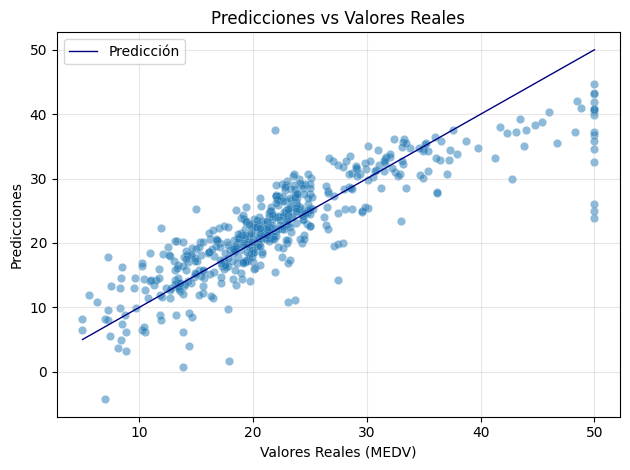

In [36]:
plt.scatter(y_boston, y_pred_boston.flatten(), alpha=0.5, edgecolors='w', linewidth=0.2)
plt.plot([y_boston.min(), y_boston.max()], [y_boston.min(), y_boston.max()], color = "navy", lw=1, label='Predicción')
plt.xlabel('Valores Reales (MEDV)')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales')
plt.legend()
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()




# Intepretación Probabilistica.

Supongamos que tenemos una caracteristica $x_i$ con m valores de entrenamiento, si asumimos que cada valor $y_i$ presenta una dispersión gaussiana $\epsilon_i$, cada $y_i$ podrá tener el siguiente valor:

$y^{i} = \Theta^T X^{(i)} + \epsilon_i$

Asumiendo ademas que el ruido gaussiando es aleatorio y esta distribuido de forma identica, con media cero y varianza $\sigma$, tenemos que la probabilidad de que la cantidad y tenga  dispersion $\epsilon_i$ es:
\begin{equation}
p(\epsilon^{(i)})=\frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( \epsilon^{(i)}\right)^2 }{2\sigma ^2}}
\end{equation}

Escribiendo, lo anterior en terminos de la probabilidad de obtener un valor de $y^{i}$ dado un $x^{i}$ parametrizado por $\theta$ obtenemos que:


\begin{equation}
p_i(y^{i}|x^{i};\theta)=\frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( y_i - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}}
\end{equation}



Si ausmimos independencia estadística de cada $\epsilon^{(i)}$, la probabilidad $L(\theta)$ asociada a toda la distribución de puntos viene dada por:

\begin{equation}
\cal{L}(\theta) = p(\vec{y}|X;\theta)=\prod_{i=1}^{n} p_i(y^{i}|x^{i};\theta)
\end{equation}



\begin{equation}
\cal{L}(\theta) =\prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( y_i - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}}
\end{equation}

para tener la mejor estimación posible de los valores que se deben elegir de  $\theta$, se escogeran los parámetros que generan la mayor probabilidad de ocurrencia según las observaciones, es decir, aquellos valores para el cual $L(\theta)$ es máximo, si aplicamos el logaritmo natural antes de máximar tenemos que:

\begin{equation}
\ln \cal{L}(\theta) = \cal{l}(\theta) = \ln \left[\prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( y_i - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}} \right]
\end{equation}


Después de un par de pasos se puede encontrar que:

\begin{equation}
\cal{l}(\theta) = n\ln \frac{1}{\sqrt{2\pi\sigma}} - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (y^{i}-\Theta^T X^{i})^2
\end{equation},

maximar $\cal{l(\theta)}$ equivale a encontrar donde  $\nabla_{\theta} \cal{l(\theta)} = 0$. Lo anterior muestra por que la elección de minimos cuadrados puede ser una buena eleccción para el analisis de los datos.

# Intepretación Probabilistica de la regularizacion.

Supongamos adicionalmente que el vector de parámetros $\theta$ también es aleatorio, es decir es un vector de variables aleatorias, con lo cual incluiríamos entonces toda la aleatoriedad posible que pueden tener los mecanismos del sistema que estamos estudiando. La distribución de $\theta$ es también una normal en función de la norma de $\theta$:

\begin{equation}
p(\theta)=\frac{1}{\sqrt{2\pi\tau}} e^{-\frac{ \left| \theta \right|^2 }{2 \tau ^2}}
\end{equation}

Tenemos como en el caso anterior que tanto las caracteristicas x como y son variables aleatorias y que si tenemos una caracteristica $x_i$ cada valor $y_i$ presenta una dispersión gaussiana $\epsilon_i$:

$y^{i} = \Theta^T X^{(i)} + \epsilon_i$

Asumiendo de nuevo que el ruido gaussiando es aleatorio y esta distribuido de forma identica, con media cero y varianza $\sigma$, tenemos que la probabilidad de que la cantidad y tenga  dispersion $\epsilon_i$ es:
\begin{equation}
p(\epsilon^{(i)})=\frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( \epsilon^{(i)}\right)^2 }{2\sigma ^2}}
\end{equation}

Ahora por la ley de Bayes podemos expresar la probabilidad de $\theta$ dados los datos $X$ y $y$ y preguntarmos por los valores de $\theta$ que maximizan la probabilidad.

\begin{equation}
p(\theta | X, y) = \frac{p(X,y | \theta) p(\theta)} {p(X,Y)}
 = \frac{P(y | X, \theta) p(\theta)}{p(Y|X)}
\end{equation}
donde asumimos la independencia de $X$ de $\theta$ con la propiedad $p(X|\theta)=p(X)$

El máximo de la probabilidad se obtiene maximizando el nominador pues el denominador no depende de $\theta$. Estos parámetros que se obtienen por este método se denominan Maximum a Posteriori MAP. Note que la expresión es la misma anterior excepto que ahora está multiplicada por la probabilidad de $\theta$

Igualmente tenemos la probabilidad de obtener un valor de $y^{i}$ dado un $x^{i}$ y un $\theta$ dados por:


\begin{equation}
p_i(y^{i}|x^{i},\theta)=\frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( y_i - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}}
\end{equation}
